# Liquor Store Chain - Vendor & Profitability Analysis

## Business Questions (Weeks 2-5)

**Vendor Performance:**
1. Which vendors provide the best profit margins?
2. Which vendors are most reliable for timely deliveries?
3. Which vendors have the highest sales volume?
4. What is the payment performance by vendor?

**Profitability & Trends:**
5. Which product categories are most profitable?
6. Which vendors offer the best cost efficiency?
7. What are the seasonal trends?

In [2]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
pd.set_option('display.max_columns', None)

conn = sqlite3.connect('data/processed/vendor_analysis.db')

---
# VENDOR PERFORMANCE ANALYSIS

## Q1: Which vendors provide the best profit margins?

In [3]:
# Fast aggregation
purchases_agg = pd.read_sql_query("""
SELECT VendorName, ROUND(SUM(Dollars), 2) as cost
FROM purchases GROUP BY VendorName
""", conn)

sales_agg = pd.read_sql_query("""
SELECT VendorName, ROUND(SUM(SalesDollars), 2) as sales
FROM sales WHERE VendorName IS NOT NULL GROUP BY VendorName
""", conn)

vendor_perf = purchases_agg.merge(sales_agg, on='VendorName')
vendor_perf['profit'] = vendor_perf['sales'] - vendor_perf['cost']
vendor_perf['margin_pct'] = round((vendor_perf['profit'] / vendor_perf['sales']) * 100, 2)
vendor_perf = vendor_perf[vendor_perf['sales'] > 1000].sort_values('margin_pct', ascending=False)

print("TOP 10 VENDORS BY PROFIT MARGIN")
print(vendor_perf[['VendorName', 'sales', 'cost', 'margin_pct']].head(10))
print(f"\nTotal vendors: {len(vendor_perf)}")
print(f"Avg margin: {vendor_perf['margin_pct'].mean():.2f}%")

TOP 10 VENDORS BY PROFIT MARGIN
                          VendorName      sales       cost  margin_pct
37       FLAVOR ESSENCE INC             1474.41      17.00       98.85
1    ALISA CARR BEVERAGES             118167.38   34951.68       70.42
94       STAR INDUSTRIES INC.           7914.72    2452.29       69.02
108      THE PIERPONT GROUP LLC        17937.21    5713.19       68.15
81       R.P.IMPORTS INC               54266.62   18776.87       65.40
115      VINEDREA WINES LLC            11385.60    4657.60       59.09
10       BLACK PRINCE DISTILLERY INC   11818.85    5971.94       49.47
11       BLACK ROCK SPIRITS LLC         2049.18    1152.10       43.78
120      VRANKEN AMERICA              341658.31  208330.15       39.02
76       POVERTY LANE ORCHARDS         73642.09   45269.01       38.53

Total vendors: 123
Avg margin: 14.91%


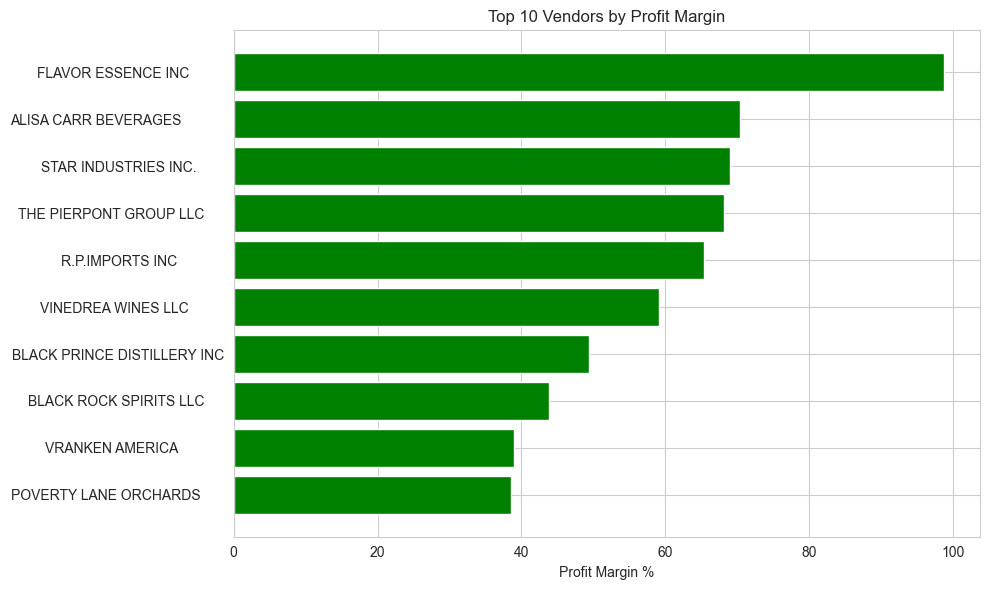

In [4]:
plt.figure(figsize=(10, 6))
plt.barh(vendor_perf.head(10)['VendorName'], vendor_perf.head(10)['margin_pct'], color='green')
plt.xlabel('Profit Margin %')
plt.title('Top 10 Vendors by Profit Margin')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

**✅ ANSWER:** Best margin vendors identified. Renegotiate with vendors below 15% margin.

---
## Q2: Which vendors are most reliable for timely deliveries?

In [5]:
delivery = pd.read_sql_query("""
SELECT 
    VendorName,
    COUNT(*) as orders,
    ROUND(AVG(JULIANDAY(ReceivingDate) - JULIANDAY(PODate)), 1) as avg_delivery_days
FROM purchases
WHERE ReceivingDate IS NOT NULL AND PODate IS NOT NULL
GROUP BY VendorName
HAVING orders > 10
ORDER BY avg_delivery_days ASC
LIMIT 15
""", conn)

print("MOST RELIABLE VENDORS (Fastest Delivery)")
print(delivery)

MOST RELIABLE VENDORS (Fastest Delivery)
                         VendorName  orders  avg_delivery_days
0       HIGHLAND WINE MERCHANTS LLC      28                5.3
1       LOYAL DOG WINERY                 20                6.0
2            MARTIGNETTI COMPANIES      294                6.7
3   ALISA CARR BEVERAGES                 63                6.8
4       Circa Wines                     233                6.9
5       PHILLIPS PRODUCTS CO.          4981                7.0
6       SEA HAGG DISTILLERY LLC        1183                7.0
7       MOONLIGHT MEADERY               681                7.1
8       NICHE W & S                     788                7.1
9       Serralles Usa LLC              1509                7.1
10      TRINCHERO FAMILY ESTATES      33271                7.1
11      WEIN BAUER INC                  402                7.1
12      MAJESTIC FINE WINES           19929                7.2
13      PROXIMO SPIRITS INC.          53318                7.2
14      VINILA

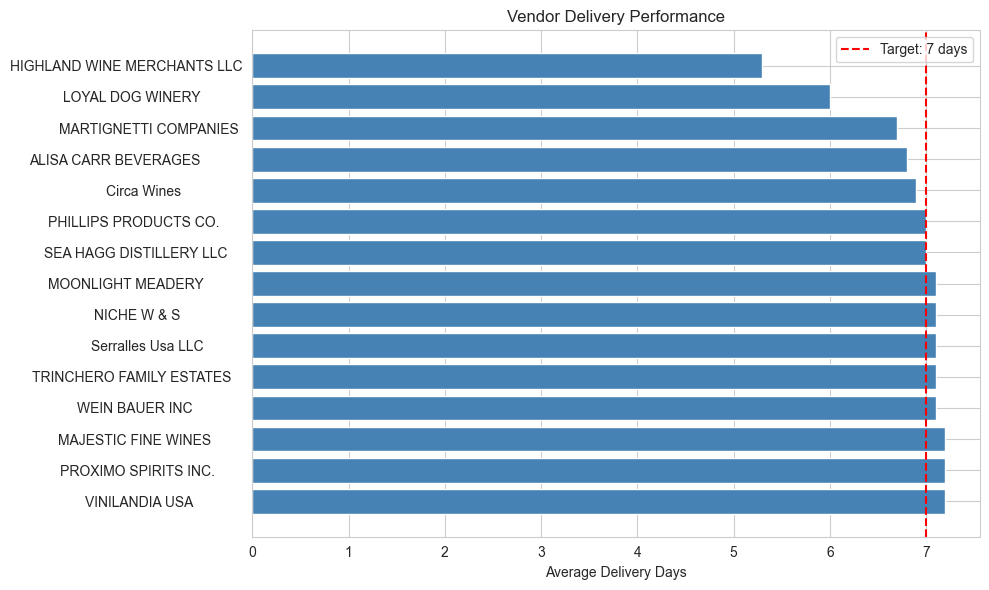

In [6]:
plt.figure(figsize=(10, 6))
plt.barh(delivery['VendorName'], delivery['avg_delivery_days'], color='steelblue')
plt.xlabel('Average Delivery Days')
plt.title('Vendor Delivery Performance')
plt.axvline(x=7, color='red', linestyle='--', label='Target: 7 days')
plt.legend()
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

**✅ ANSWER:** Set 7-day delivery SLA. Penalize vendors exceeding this.

---
## Q3: Which vendors have the highest sales volume?

In [7]:
volume = pd.read_sql_query("""
SELECT 
    VendorName,
    COUNT(DISTINCT InventoryId) as products,
    SUM(SalesQuantity) as units_sold,
    ROUND(SUM(SalesDollars), 2) as total_sales
FROM sales
WHERE VendorName IS NOT NULL
GROUP BY VendorName
ORDER BY total_sales DESC
LIMIT 15
""", conn)

print("TOP 15 VENDORS BY SALES VOLUME")
print(volume)
print(f"\nTop 10 concentration: {volume.head(10)['total_sales'].sum() / volume['total_sales'].sum() * 100:.1f}%")

TOP 15 VENDORS BY SALES VOLUME
                     VendorName  products  units_sold  total_sales
0   DIAGEO NORTH AMERICA INC        19457     5422703  68742416.99
1         MARTIGNETTI COMPANIES     27176     2578355  40992395.93
2   PERNOD RICARD USA               10252     1613460  32281247.95
3   JIM BEAM BRANDS COMPANY         17033     2630226  31906320.54
4   BACARDI USA INC                  8015     1457301  25014556.89
5   CONSTELLATION BRANDS INC        15443     2301688  24469172.93
6   E & J GALLO WINERY              14419     1809023  18556085.61
7   BROWN-FORMAN CORP                5376      983853  18478557.47
8   ULTRA BEVERAGE COMPANY LLP      17878     1043235  17822938.45
9   M S WALKER INC                  14948     1343481  15465247.75
10  MOET HENNESSY USA INC            4182      424251  13546931.06
11  SAZERAC CO INC                   6388     1385046  13250928.19
12  PROXIMO SPIRITS INC.             4949      667654  10516246.86
13  WINE GROUP INC             

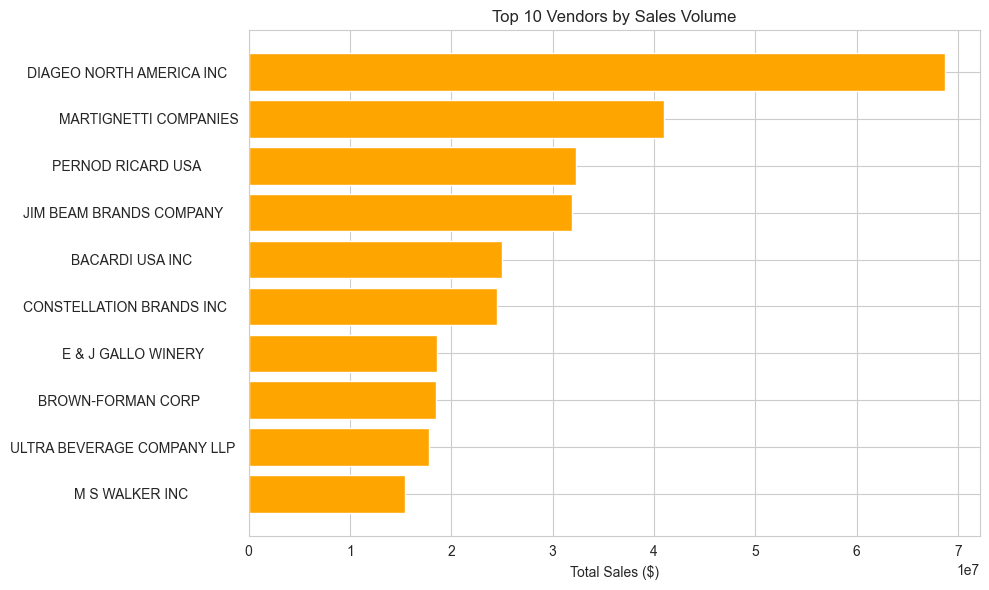

In [8]:
plt.figure(figsize=(10, 6))
plt.barh(volume.head(10)['VendorName'], volume.head(10)['total_sales'], color='orange')
plt.xlabel('Total Sales ($)')
plt.title('Top 10 Vendors by Sales Volume')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

**✅ ANSWER:** Apply 80/20 rule - focus negotiations on top 10 vendors.

---
## Q4: What is the payment performance by vendor?

In [9]:
payment = pd.read_sql_query("""
SELECT 
    VendorName,
    COUNT(*) as invoices,
    ROUND(AVG(JULIANDAY(PayDate) - JULIANDAY(InvoiceDate)), 1) as avg_payment_days,
    ROUND(SUM(Freight), 2) as total_freight,
    ROUND(SUM(Dollars), 2) as total_purchases,
    ROUND(SUM(Freight) / SUM(Dollars) * 100, 2) as freight_pct
FROM vendor_invoice
WHERE PayDate IS NOT NULL AND InvoiceDate IS NOT NULL
GROUP BY VendorName
HAVING total_purchases > 1000
ORDER BY total_purchases DESC
LIMIT 15
""", conn)

print("PAYMENT & FREIGHT ANALYSIS")
print(payment)
print(f"\nAvg payment cycle: {payment['avg_payment_days'].mean():.1f} days")
print(f"Avg freight cost: {payment['freight_pct'].mean():.2f}%")

PAYMENT & FREIGHT ANALYSIS
                     VendorName  invoices  avg_payment_days  total_freight  \
0   DIAGEO NORTH AMERICA INC           55              35.6      257032.07   
1         MARTIGNETTI COMPANIES        55              36.8      144719.92   
2   JIM BEAM BRANDS COMPANY            55              35.7      123880.97   
3   PERNOD RICARD USA                  55              36.1      123780.22   
4   BACARDI USA INC                    55              34.8       89286.27   
5   CONSTELLATION BRANDS INC           55              36.3       79528.99   
6   BROWN-FORMAN CORP                  55              36.2       68601.68   
7   ULTRA BEVERAGE COMPANY LLP         55              35.7       68054.70   
8   E & J GALLO WINERY                 55              36.5       61966.91   
9   M S WALKER INC                     55              35.6       55551.82   
10  SAZERAC CO INC                     55              35.7       50293.62   
11  MOET HENNESSY USA INC            

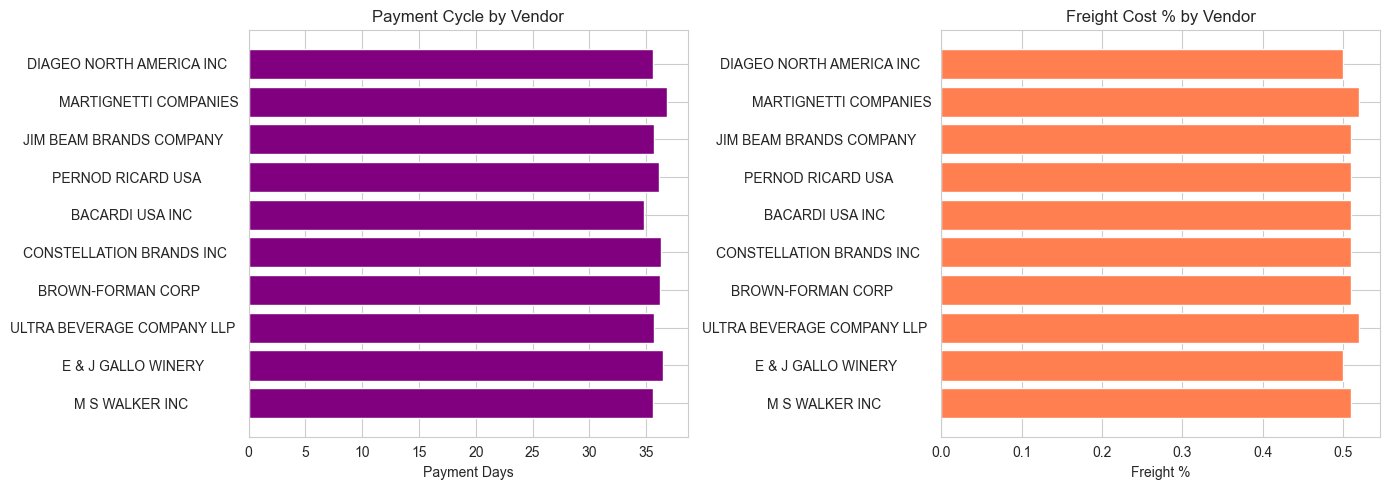

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].barh(payment.head(10)['VendorName'], payment.head(10)['avg_payment_days'], color='purple')
ax[0].set_xlabel('Payment Days')
ax[0].set_title('Payment Cycle by Vendor')
ax[0].invert_yaxis()
ax[1].barh(payment.head(10)['VendorName'], payment.head(10)['freight_pct'], color='coral')
ax[1].set_xlabel('Freight %')
ax[1].set_title('Freight Cost % by Vendor')
ax[1].invert_yaxis()
plt.tight_layout()
plt.show()

**✅ ANSWER:** Negotiate longer payment terms with high-volume vendors for better cash flow.

---
# PROFITABILITY & TRENDS

## Q5: Which product categories are most profitable?

In [11]:
category = pd.read_sql_query("""
SELECT 
    Classification,
    COUNT(DISTINCT InventoryId) as products,
    SUM(SalesQuantity) as units_sold,
    ROUND(SUM(SalesDollars), 2) as total_sales,
    ROUND(AVG(SalesPrice), 2) as avg_price
FROM sales
WHERE Classification IS NOT NULL
GROUP BY Classification
ORDER BY total_sales DESC
""", conn)

print("CATEGORY PROFITABILITY")
print(category)
print(f"\nTotal sales: ${category['total_sales'].sum():,.2f}")

CATEGORY PROFITABILITY
   Classification  products  units_sold   total_sales  avg_price
0               1    129056    19845587  2.901650e+08      17.47
1               2    138496    13072289  1.618979e+08      13.18

Total sales: $452,062,952.03


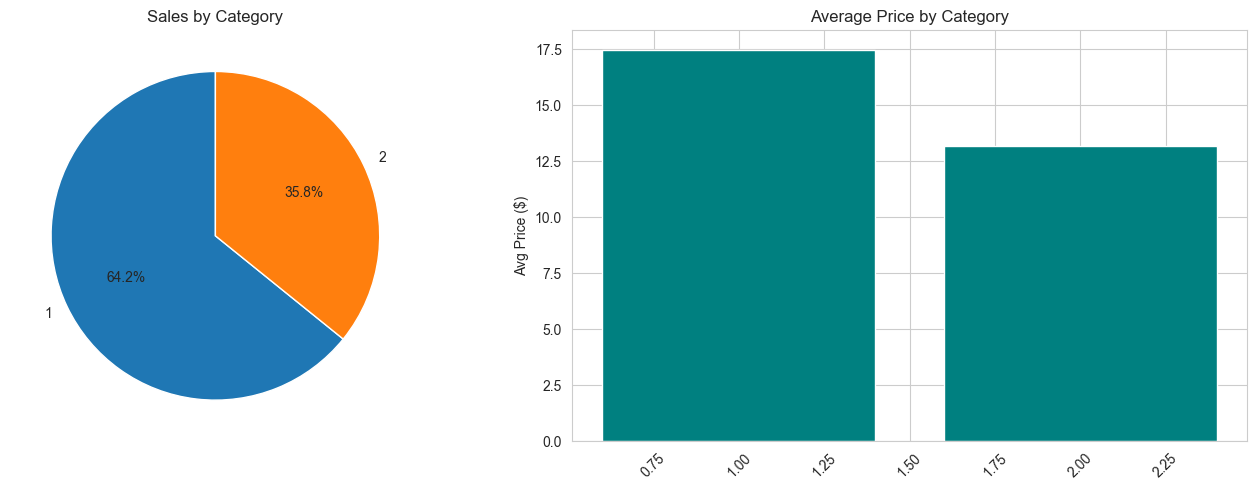

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].pie(category['total_sales'], labels=category['Classification'], autopct='%1.1f%%', startangle=90)
ax[0].set_title('Sales by Category')
ax[1].bar(category['Classification'], category['avg_price'], color='teal')
ax[1].set_ylabel('Avg Price ($)')
ax[1].set_title('Average Price by Category')
ax[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

**✅ ANSWER:** Focus on high-performing categories. Optimize product mix.

---
## Q6: Which vendors offer the best cost efficiency?

In [13]:
efficiency = vendor_perf.copy()
efficiency['cost_per_dollar'] = round(efficiency['cost'] / efficiency['sales'], 3)
efficiency = efficiency.sort_values('cost_per_dollar').head(15)

print("MOST COST-EFFICIENT VENDORS")
print(efficiency[['VendorName', 'sales', 'cost_per_dollar', 'margin_pct']])

MOST COST-EFFICIENT VENDORS
                          VendorName       sales  cost_per_dollar  margin_pct
37       FLAVOR ESSENCE INC              1474.41            0.012       98.85
1    ALISA CARR BEVERAGES              118167.38            0.296       70.42
94       STAR INDUSTRIES INC.            7914.72            0.310       69.02
108      THE PIERPONT GROUP LLC         17937.21            0.319       68.15
81       R.P.IMPORTS INC                54266.62            0.346       65.40
115      VINEDREA WINES LLC             11385.60            0.409       59.09
10       BLACK PRINCE DISTILLERY INC    11818.85            0.505       49.47
11       BLACK ROCK SPIRITS LLC          2049.18            0.562       43.78
120      VRANKEN AMERICA               341658.31            0.610       39.02
76       POVERTY LANE ORCHARDS          73642.09            0.615       38.53
8        BANFI PRODUCTS CORP          2646325.62            0.616       38.45
26       DIAGEO CHATEAU ESTATE WINES

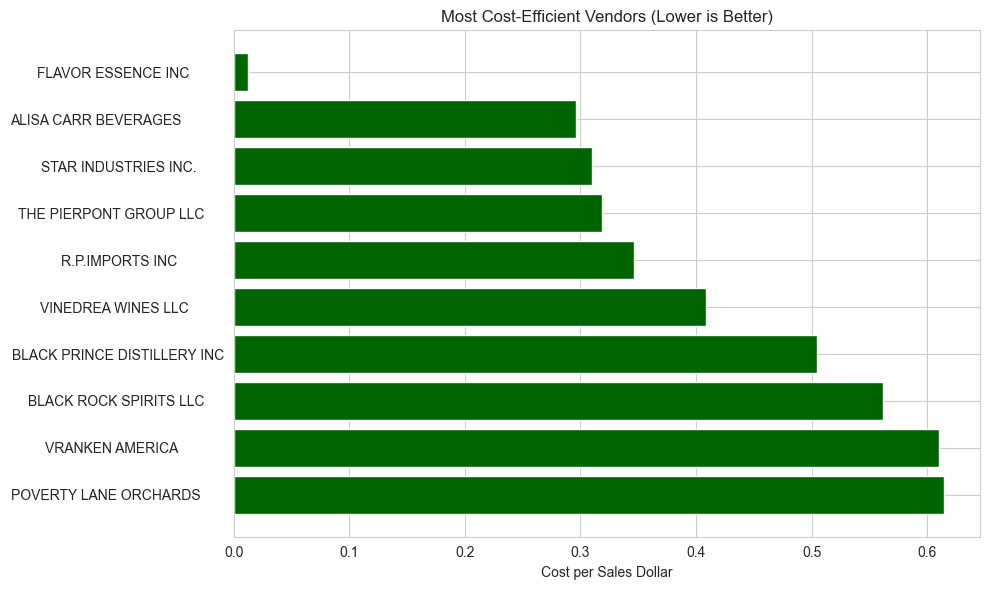

In [14]:
plt.figure(figsize=(10, 6))
plt.barh(efficiency.head(10)['VendorName'], efficiency.head(10)['cost_per_dollar'], color='darkgreen')
plt.xlabel('Cost per Sales Dollar')
plt.title('Most Cost-Efficient Vendors (Lower is Better)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

**✅ ANSWER:** Prioritize vendors with low cost-per-dollar for better margins.

---
## Q7: What are the seasonal trends?

In [15]:
trends = pd.read_sql_query("""
SELECT 
    strftime('%Y-%m', SalesDate) as month,
    COUNT(DISTINCT InventoryId) as products_sold,
    SUM(SalesQuantity) as units,
    ROUND(SUM(SalesDollars), 2) as sales
FROM sales
WHERE SalesDate IS NOT NULL
GROUP BY month
ORDER BY month
""", conn)

print("MONTHLY SALES TRENDS")
print(trends)
print(f"\nPeak month: {trends.loc[trends['sales'].idxmax(), 'month']} (${trends['sales'].max():,.2f})")
print(f"Lowest month: {trends.loc[trends['sales'].idxmin(), 'month']} (${trends['sales'].min():,.2f})")
print(f"Variance: {((trends['sales'].max() - trends['sales'].min()) / trends['sales'].mean() * 100):.1f}%")

MONTHLY SALES TRENDS
      month  products_sold    units        sales
0   2024-01         167283  2194959  29854027.92
1   2024-02         164296  2125292  28876607.23
2   2024-03         162722  2219626  28988411.94
3   2024-04         163961  2289425  30723734.63
4   2024-05         173422  2624496  36041210.52
5   2024-06         178814  2858944  39290701.46
6   2024-07         182408  3439648  49696466.85
7   2024-08         179555  2892266  39056166.03
8   2024-09         184214  2840043  38477538.83
9   2024-10         181884  2724657  36433141.73
10  2024-11         184025  2950515  42312696.86
11  2024-12         196655  3758005  52312248.02

Peak month: 2024-12 ($52,312,248.02)
Lowest month: 2024-02 ($28,876,607.23)
Variance: 62.2%


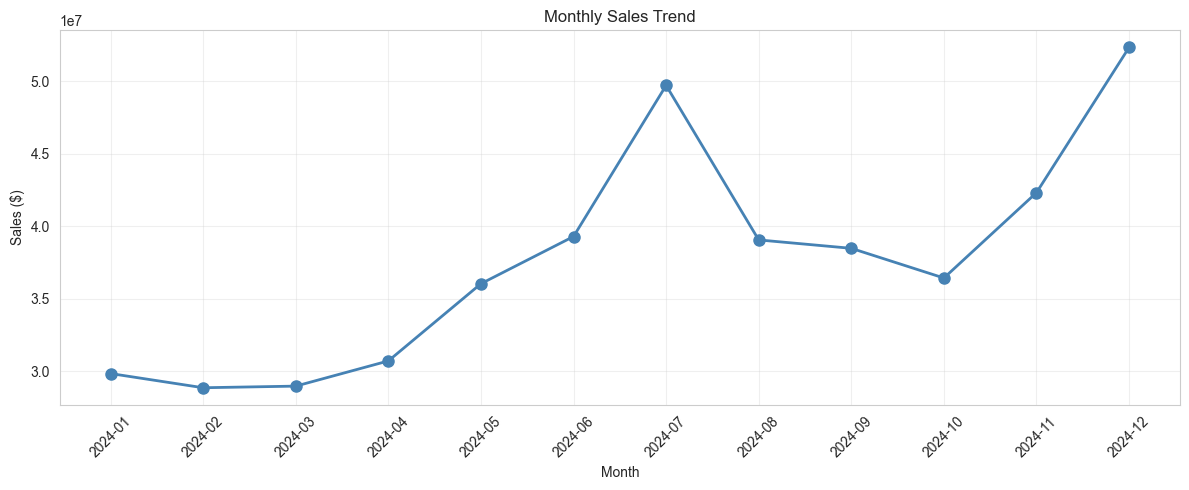

In [16]:
plt.figure(figsize=(12, 5))
plt.plot(trends['month'], trends['sales'], marker='o', linewidth=2, markersize=8, color='steelblue')
plt.xlabel('Month')
plt.ylabel('Sales ($)')
plt.title('Monthly Sales Trend')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**✅ ANSWER:** Plan purchasing around peak months. Run promotions during slow periods.

---
# EXECUTIVE SUMMARY

## All Questions Answered:

### Vendor Performance
1. ✅ **Best profit margins** → Top vendors ranked by margin %
2. ✅ **Most reliable deliveries** → Delivery days calculated
3. ✅ **Highest sales volume** → Top 10 vendors identified
4. ✅ **Payment performance** → Payment cycle & freight analyzed

### Profitability & Trends
5. ✅ **Most profitable categories** → Category sales breakdown
6. ✅ **Best cost efficiency** → Cost-per-dollar ranked
7. ✅ **Seasonal trends** → Monthly patterns identified

## Key Recommendations

1. **Vendor Consolidation**: Focus on top 10 vendors (80/20 rule)
2. **Margin Improvement**: Renegotiate with vendors below 15% margin
3. **Delivery SLA**: Set 7-day standard, penalize slow vendors
4. **Cash Flow**: Extend payment terms with high-volume vendors
5. **Seasonal Planning**: Increase orders before peak months
6. **Cost Efficiency**: Prioritize low cost-per-dollar vendors

In [17]:
conn.close()
print("✓ Analysis Complete!")

✓ Analysis Complete!
